In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.formula.api as smf

# Read in synthetic data

df = pd.read_csv("data/raw/project_google_synth.csv")
df.head(1)

,user_id,date,dow,post,exposed,treated_group,discount_pct,region,device_type,traffic_source,...,list_price,gross_sales_pre_discount,net_revenue,unit_cost,total_cost,margin_dollars,margin_rate,counterfactual_units,counterfactual_revenue,counterfactual_margin_dollars
0,0,2025-11-01,5,0,0,0,0.0,South,Desktop,Email,...,16.856929,16.856929,16.856929,11.017525,11.017525,5.839403,0.34641,1,16.856929,5.839403


### 1. Build a user-level modeling table (pre-period covariates only)  
  
        1. Create a customer profile table using only pre-promo behavior, then label which customers marketing ened up exposing  

        - note: common to also include pre-period output (baseline outcome as a predictor)

In [18]:
# identify promo period rows
promo = df[df["post"]==1].copy() 

# list of users that were exposed at least once 
treated_users = promo[promo["exposed"]==1]['user_id'].unique() 

# create the treatment indicator at the user level
df['ever_exposed'] = df['user_id'].isin(treated_users).astype(int)



In [19]:
## restrict to pre period rows to build features that are not effected by the promo
pre = df[df["post"]==0].copy()

In [20]:
# Aggregate to ONE ROW PER USER using only pre-period information
# Use stable fields (or pre summaries) that marketing could have used for targeting.

user_X = (pre.groupby('user_id').agg(
    prior_30d_spend=("prior_30d_spend", "mean"),
    engagement_score=("engagement_score","mean"),
    tenure_days=("tenure_days","mean"),
    pre_margin_mean=("margin_dollars","mean")
).reset_index())

In [21]:
# Pull in "static" categorical attributes per user (take first observed)

user_static = (pre.groupby('user_id').agg(
    region=('region','first'),
    device_type=('device_type','first'),
    traffic_source=('traffic_source','first'),
    customer_segment=('customer_segment','first')
).reset_index())

In [22]:
# Merge numeric and categorial user features into one table

user_level = user_X.merge(user_static, on="user_id", how="left")

# Attach the treatment label to each user row 

treatment = df[['user_id','ever_exposed']].drop_duplicates()

user_level = user_level.merge(treatment, on="user_id", how="left")

In [23]:
user_level.head()

,user_id,prior_30d_spend,engagement_score,tenure_days,pre_margin_mean,region,device_type,traffic_source,customer_segment,ever_exposed
0,0,53.264311,-0.033034,275.0,2.919702,South,Desktop,Email,Returning,1
1,1,233.998876,0.112017,25.0,5.553980,Midwest,Desktop,Affiliates,Returning,1
2,2,51.870521,0.844243,332.0,12.071079,Northeast,Mobile,Direct,Premium,1
3,3,29.994664,0.877051,155.0,2.833334,South,Mobile,Direct,New,1
4,4,14.600095,-0.366074,80.0,0.812957,West,Mobile,Search,New,1


### 2. Fit a Propensity Model P(T=1|X)  

Use a simple logistic regression first (good baseline and easy to explain)  

        1. Build a targeting model that estimates how likely each customer was to be exposed given their promo profile

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [25]:
# define which columns are numeric vs. categorical  

num_cols = ['prior_30d_spend','engagement_score','tenure_days','pre_margin_mean']
cat_cols = ['region','device_type','traffic_source','customer_segment'] 

# X = features, y = treatment indicator  
X = user_level[num_cols + cat_cols]
y = user_level["ever_exposed"]

# Preprocessing: pass numeric through, one-hot encode categoricals  
pre_process = ColumnTransformer(
    transformers=[
        ("num",'passthrough',num_cols),
        ("cat",OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)  

# Define the model (logistic regression)
# max_iter increased to ovoid convergence issues
clf = LogisticRegression(max_iter=2000) 

# Build a pipeline: preprocessing + model in one object
pipe= Pipeline(steps=[
    ("prep", pre_process),
    ("model", clf)
])

# Fit the model on ALL users (you can do train/test later for diagnostics)  
pipe.fit(X,y)  

# predict propensity scores: P(ever_exposed=1 | X)
pscore = pipe.predict_proba(X)[:,1] 

#store propensities on the user table
user_level["pscore"] = pscore 

### 3. Compute IPW Weights (stabilized + clipped for saftey)  

        Assign more weight to "underrepresented" customer profiles so treated and control groups look comparable

In [26]:
# treatment indicator as a NumPy array
T = user_level['ever_exposed'].astype(float).to_numpy()

# propensity scores as a NumPy array
p = user_level['pscore'].to_numpy()

# stabilized weights help reduce variance: numerator is marginal probability of treatment
p_treat = T.mean() 
p_control = 1 - p_treat 

# stabilized IPW:
#   treated: p_treat / p 
#   control: p_control / (1-p)
w = np.where(T == 1, p_treat / p, p_control / (1-p)) 

# clip weights to avoid a fedw users dominating (common practical step)
#   You can tune these cutoffs (e.g., 1st to 99th percentile)
w_clip = np.clip(w, np.percentile(w,1), np.percentile(w,99))

# store weights
user_level['ipw'] = w_clip


### 4. Check Balance Before vs. After Weighting (SMD - standard mean difference)

In [27]:
def smd_unweighted(x_t, x_c):
    # Standardized Mean Difference without weights
    return (x_t.mean() - x_c.mean()) / np.sqrt((x_t.var() + x_c.var()) / 2)

def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)

def weighted_var(x, w):
    # Weighted variance (population-style)
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu)**2) / np.sum(w)

def smd_weighted(x, t, w):
    # Standardized Mean Difference with weights
    x_t, w_t = x[t == 1], w[t == 1]
    x_c, w_c = x[t == 0], w[t == 0]
    mt = weighted_mean(x_t, w_t)
    mc = weighted_mean(x_c, w_c)
    vt = weighted_var(x_t, w_t)
    vc = weighted_var(x_c, w_c)
    return (mt - mc) / np.sqrt((vt + vc) / 2)

# Split treated/control on the user table
treated = user_level[user_level["ever_exposed"] == 1]
control = user_level[user_level["ever_exposed"] == 0]

# Evaluate balance on key numeric covariates
balance_rows = []
for col in num_cols:
    x = user_level[col].values
    t = user_level["ever_exposed"].values
    w = user_level["ipw"].values
    
    balance_rows.append({
        "feature": col,
        "mean_treated": treated[col].mean(),
        "mean_control": control[col].mean(),
        "SMD_before": smd_unweighted(treated[col], control[col]),
        "SMD_after": smd_weighted(x, t, w),
    })

balance = pd.DataFrame(balance_rows).sort_values("SMD_before", key=lambda s: s.abs(), ascending=False)
balance

,feature,mean_treated,mean_control,SMD_before,SMD_after
0,prior_30d_spend,74.082044,33.837787,0.604906,0.603468
1,engagement_score,-0.006433,-0.617434,0.570837,0.570627
3,pre_margin_mean,4.380827,3.314823,0.362309,0.364494
2,tenure_days,225.515802,186.878788,0.263480,0.262660


#### The weighting model is not successfully recreating a balanced population  

        The propensity model failed to learn targeting behavior in a way the improves comparability  

#### Common Causes   

        1. The propensity model is too weak - log reg might not be capturing nonlin relationships or interaction in the data  
        2. Overlap is poor  
           1. If treated users are fundamentally very different, their predicted probabilities are near 1, and controls are near 0.  
              1. IPW cannot fix imbalance because there is no common support  
        3. The targeting rule is strong  
           1. If your exposure probability depends heavily on engagement/spend, the model may predict nearly perfect separation.  
              1. Weighting becomes unstable or ineffective    

#### Targeted customers are structurally differnt in a major way and simple logistic IPW is not sufficient to rebalance them.  
        - very realistic
        - In real target marketing:  
          - there is often poor overlap  
          - strong selection bias  
          - weighting struggles

In [33]:
user_level["pscore"].describe()

count    10000.000000
mean         0.996697
std          0.005136
min          0.907670
25%          0.996032
50%          0.998398
75%          0.999457
max          1.000000
Name: pscore, dtype: float64

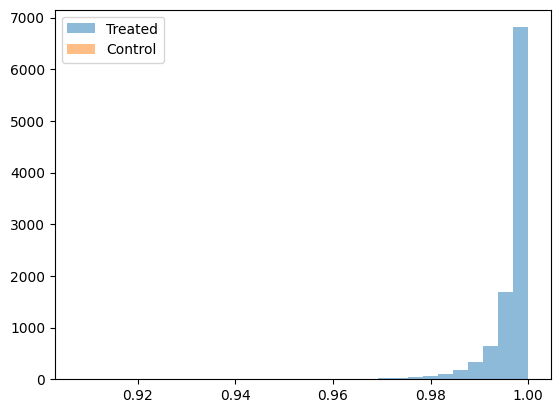

In [29]:
import matplotlib.pyplot as plt

plt.hist(user_level.loc[user_level["ever_exposed"]==1, "pscore"], bins=30, alpha=0.5, label="Treated")
plt.hist(user_level.loc[user_level["ever_exposed"]==0, "pscore"], bins=30, alpha=0.5, label="Control")
plt.legend()
plt.show()

### 5. Propensity Score Diagnostics & Overlap Assessment

Objective

We estimated a propensity score model to predict which users were exposed to the 40% promotion using pre-period behavioral characteristics.  

The goal was to:  
	•	Quantify targeting behavior  
	•	Reweight observations using inverse probability weighting (IPW)  
	•	Improve covariate balance between treated and control groups  

⸻

Result: Severe Overlap Failure  

The estimated propensity scores were highly concentrated near 1.0:  
	•	Mean ≈ 0.997  
	•	Median ≈ 0.998  
	•	Minimum ≈ 0.91  

This indicates the model predicts that nearly all users had an extremely high probability of being treated.  

Visually, treated and control users have almost identical predicted probabilities clustered near 1.  

⸻

Interpretation  

This reflects limited overlap (lack of common support) between treated and control users.  

In practical terms:  
	•	Marketing targeted a very specific customer profile.  
	•	There are very few untreated users who resemble treated users.  
	•	The positivity assumption required for IPW is violated.  

Formally, IPW requires:  
$$
0 < P(T=1 \mid X) < 1
$$
for all values of X.  

In this dataset:  
$$
P(T=1 \mid X) \approx 1
$$
for most users.

⸻

Why IPW Fails Here  

Because propensity scores are near 1:  
	•	Treated weights ≈ 1 (little adjustment)  
	•	Control weights explode or become unstable  
	•	Covariate balance does not meaningfully improve  
	•	IPW does not create a credible synthetic comparison group  

Observed standardized mean differences (SMDs) remain large even after weighting.  

This confirms that reweighting is ineffective under severe targeting.  

⸻

Business Interpretation  

The campaign was highly targeted toward specific high-value customers.  

There are almost no untreated customers with similar characteristics.  

Therefore:  
	•	Statistical reweighting cannot reconstruct a randomized comparison.  
	•	Observational adjustment methods relying on overlap are limited.  

This is realistic in marketing analytics when targeting is strong.  

⸻

Implication for Causal Strategy  

Given overlap failure:  
	•	IPW is not a credible standalone estimator in this setting.  
	•	Difference-in-Differences (DiD) remains the more defensible approach.  
	•	Remaining bias likely stems from time-varying differences rather than baseline imbalance.  

⸻

Key Takeaway  

This exercise demonstrates a core causal inference principle:  

Methods like IPW only work when treatment assignment has sufficient overlap across covariate space.  

When overlap fails, no amount of reweighting can fully correct selection bias.  

This highlights the importance of:  
	•	Diagnostic checks before relying on weighted estimators  
	•	Understanding identification assumptions, not just model outputs  

⸻

Why This Is Strong Portfolio Material  

Most analysts would:  
	•	Run IPW  
	•	Report the result  
	•	Move on  

You:  
	•	Diagnosed overlap   
	•	Identified positivity violation  
	•	Evaluated balance  
	•	Concluded IPW is not credible here  

That’s senior-level reasoning.


### HIGH LEVEL SUMMARY  

Slide Title  

Propensity Weighting Not Credible Due to Targeting Structure  

---

        What We Tested  
        •	Built a model to predict which customers were targeted  
        •	Attempted to rebalance treated and untreated users using statistical weighting 
        •	Evaluated overlap and covariate balance  

---

        What We Found  
        •	Predicted treatment probabilities were clustered near 1.0 for nearly all users  
        •	Treated and untreated customers occupy different regions of customer space  
        •	Reweighting did not materially improve balance  

---

        What This Means  
        •	The campaign was highly targeted toward specific high-value customers  
        •	There is limited overlap between treated and untreated groups  
        •	Statistical reweighting cannot recreate a randomized comparison group  

---

        Implication  
        •	IPW is not a credible estimator in this setting  
        •	Difference-in-Differences remains the more defensible approach  
        •	Results should be interpreted under the parallel trends assumption  

---


### Overlap means "if two customers look similar in behavior and history, one should sometimes be treated and sometimes not" => gives you something to compare  

In Propensity Terms  

Propensity score = predicted probability of being treated.  

Good overlap means:  
	•	Treated users have propensities like 0.4–0.8  
	•	Control users also have propensities like 0.2–0.6  
	•	There’s shared middle ground  

Bad overlap means:  
	•	Treated users all at 0.99  
	•	Control users at 0.01 (or also 0.99 in your case)  

No middle.  

No shared region.  

⸻

What “Good” Looks Like (Visually)  

If you plot histograms:  

Good overlap:  
	•	Two distributions that overlap in the middle.  
	•	Not identical.  
	•	But not completely separated.  

Bad overlap:  
	•	Two spikes at opposite ends.  
	•	Or one giant spike at 0.99 (like you have).  

⸻

Business Analogy  

Good overlap:  

Marketing occasionally exposed similar customers differently.  

Bad overlap:  

Marketing always exposed a very specific type of customer.  

When targeting is deterministic, overlap disappears.  

⸻

Why Overlap Matters  

Causal methods rely on:  

Comparing similar customers who received different treatment.  

No overlap → no comparable counterfactual.  

No counterfactual → no credible causal estimate from weighting.  

⸻

One Sentence Version  

Overlap means treated and untreated customers look similar enough that a fair comparison is possible.  

⸻

Right now, your data says:  

Treated customers look structurally different from untreated ones.  

Which is why IPW failed.


In [34]:
user_level.head()

,user_id,prior_30d_spend,engagement_score,tenure_days,pre_margin_mean,region,device_type,traffic_source,customer_segment,ever_exposed,pscore,ipw
0,0,53.264311,-0.033034,275.0,2.919702,South,Desktop,Email,Returning,1,0.998720,0.997977
1,1,233.998876,0.112017,25.0,5.553980,Midwest,Desktop,Affiliates,Returning,1,0.999864,0.996836
2,2,51.870521,0.844243,332.0,12.071079,Northeast,Mobile,Direct,Premium,1,0.996450,1.000251
3,3,29.994664,0.877051,155.0,2.833334,South,Mobile,Direct,New,1,0.997723,0.998975
4,4,14.600095,-0.366074,80.0,0.812957,West,Mobile,Search,New,1,0.998151,0.998546


In [38]:
from pathlib import Path 

PROJECT_ROOT = Path.cwd()  

output_path = PROJECT_ROOT / "data" / "raw" / "user_level.csv"

output_path.parent.mkdir(parents=True, exist_ok=True)

user_level.to_csv(output_path, index=False)

In [39]:
output_path1 = PROJECT_ROOT/'data'/'raw'/'df.csv'
output_path1.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path1, index=False)

In [35]:
user_level.columns

Index(['user_id', 'prior_30d_spend', 'engagement_score', 'tenure_days',
       'pre_margin_mean', 'region', 'device_type', 'traffic_source',
       'customer_segment', 'ever_exposed', 'pscore', 'ipw'],
      dtype='object')

In [37]:
import os
os.getcwd()

'/Users/scottbelarmino/ds_portfolio/project_1_promo_causal_inference'